<a href="https://colab.research.google.com/github/Jeffrey-AI-research/Stock-Market-Predictions-AI-Research/blob/main/Stock_Market_Predictions_AI_Research_(XGBoost).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Training Machine Learning Model (XGBoost)

In [ ]:
!pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,37.793785,148158800,AAPL
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,34.029243,365248800,AAPL
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,35.481926,234428400,AAPL
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,35.402950,219111200,AAPL
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,36.077847,164101200,AAPL


In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6290 entries, 0 to 6289
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6290 non-null   object 
 1   Open       6290 non-null   float64
 2   High       6290 non-null   float64
 3   Low        6290 non-null   float64
 4   Close      6290 non-null   float64
 5   Adj Close  6290 non-null   float64
 6   Volume     6290 non-null   int64  
 7   Ticker     6290 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 393.3+ KB


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,37.793785,148158800,AAPL
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,34.029243,365248800,AAPL
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,35.481926,234428400,AAPL
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,35.402950,219111200,AAPL
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,36.077847,164101200,AAPL


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"])
df["Target"] = df.groupby("Ticker")["Close"].shift(-1)
df["Previous_Close"] = df.groupby("Ticker")["Close"].shift(1)
df["Previous_Open"] = df.groupby("Ticker")["Open"].shift(1)
df = df.dropna()

In [ ]:
X = df[["Open","High","Low","Close","Volume","Previous_Open","Previous_Close"]]
y = df["Target"]

In [ ]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [ ]:
model = XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=3,subsample=0.8,colsample_bytree=0.8,random_state=42)

In [ ]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.9863455642605348
MAE: 9.48813556865522
RMSE: 12.64115302163617


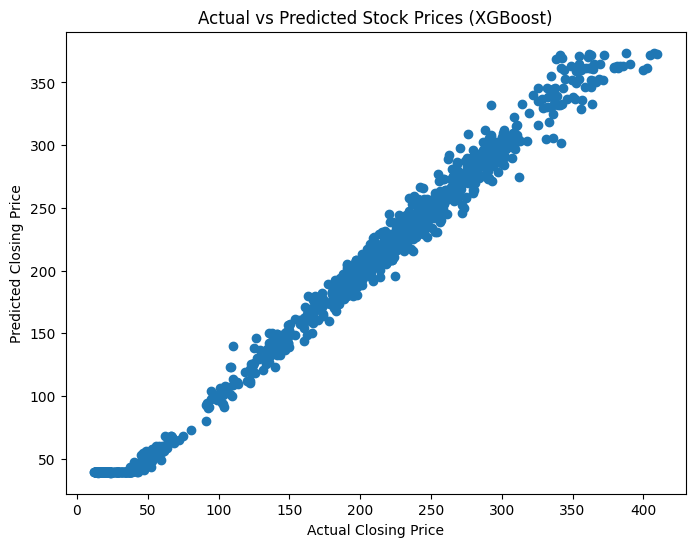

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")
plt.title("Actual vs Predicted Stock Prices (XGBoost)")
plt.show()

          Feature  Importance
2             Low    0.376458
3           Close    0.292289
1            High    0.184146
6  Previous_Close    0.102215
0            Open    0.041632
5   Previous_Open    0.003178
4          Volume    0.000082


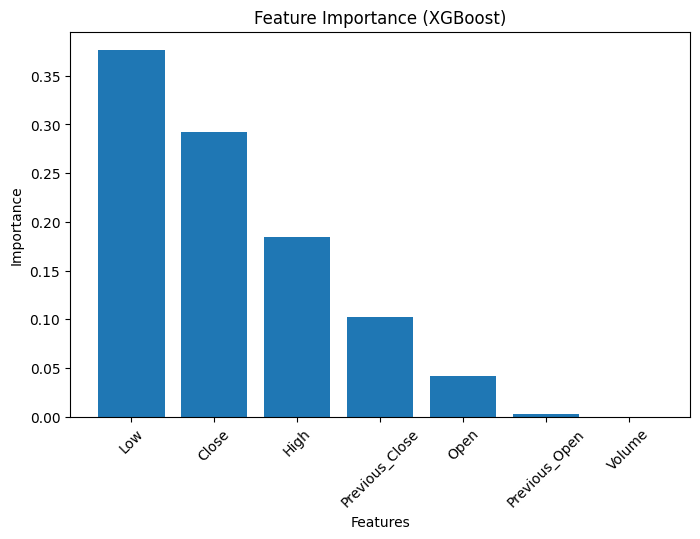

In [ ]:
importance = pd.DataFrame({"Feature": X_train.columns,"Importance": model.feature_importances_})
importance = importance.sort_values(by="Importance", ascending=False)
print(importance)
plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

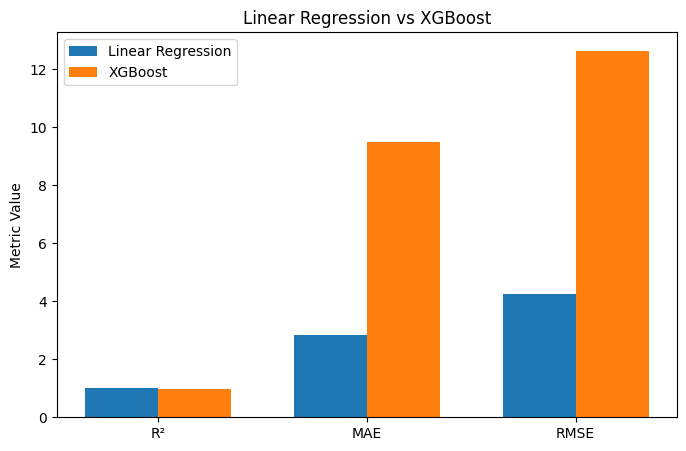

In [ ]:
metrics = ["R²", "MAE", "RMSE"]
linear = [0.9970517445839147, 2.8516404094821204, 4.242474419035115]
xgboost = [r2, mae, rmse]
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(8,5))
plt.bar(x - width/2, linear, width, label="Linear Regression")
plt.bar(x + width/2, xgboost, width, label="XGBoost")
plt.xticks(x, metrics)
plt.ylabel("Metric Value")
plt.title("Linear Regression vs XGBoost")
plt.legend()

plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()